# RetailPulse
# F-05 Inventory Optimization
Professional Industry-Ready Notebook

This notebook performs:
- ABC Analysis
- XYZ Analysis
- ABC-XYZ Matrix
- EOQ
- Safety Stock
- Reorder Point
- Inventory Status
- Inventory Turnover
- DIO
- Recommendations
- KPI Export
- Dashboard-ready CSVs

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns",None)

DATA_PATH="../data/processed/rossmann_processed1.csv"
sales=pd.read_csv(DATA_PATH)
print(sales.shape)
sales.head()


(1017209, 23)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,SalesPerCustomer
0,1,5,2015-07-31,5263,555,1,1,0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,4,9.482883
1,2,5,2015-07-31,6064,625,1,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,4,9.702400
2,3,5,2015-07-31,8314,821,1,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,4,10.126675
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,4,9.342457
4,5,5,2015-07-31,4822,559,1,1,0,1,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,4,8.626118


In [2]:
# Stable SKU generation
if "ProductID" not in sales.columns:
    sales=sales.copy()
    sales["ProductID"]=(
        sales["Store"].astype(str)+"_"+
        sales["Assortment"].astype(str)+"_"+
        sales["Promo"].astype(str)
    ).astype("category").cat.codes+1000

# Approximate unit demand from revenue
sales["UnitPrice"]=sales["Sales"]/sales["Customers"].replace(0,np.nan)
sales["UnitPrice"]=sales["UnitPrice"].fillna(sales["UnitPrice"].median()).clip(lower=5)
sales["UnitsSold"]=(sales["Sales"]/sales["UnitPrice"]).round().clip(lower=1)

inventory=sales.groupby("ProductID").agg(
AnnualDemand=("UnitsSold","sum"),
AvgDailyDemand=("UnitsSold","mean"),
DemandStd=("UnitsSold","std"),
Revenue=("Sales","sum"),
SellingDays=("UnitsSold","count")
).reset_index()

inventory["DemandStd"]=inventory["DemandStd"].fillna(0)
rng=np.random.default_rng(42)
inventory["UnitCost"]=rng.integers(50,500,len(inventory))
inventory["AnnualConsumption"]=inventory["AnnualDemand"]*inventory["UnitCost"]
inventory.head()


,ProductID,AnnualDemand,AvgDailyDemand,DemandStd,Revenue,SellingDays,UnitCost,AnnualConsumption
0,1000,220591.0,467.353814,286.198704,2316540,472,90,19853190.0
1,1001,203220.0,710.559441,174.827419,2318985,286,398,80881560.0
2,1002,228358.0,392.367698,252.653223,1805562,582,344,78555152.0
3,1003,257426.0,715.072222,144.045742,2433442,360,247,63584222.0
4,1004,289673.0,497.719931,307.842186,2306235,582,244,70680212.0


In [3]:
# ABC
inventory=inventory.sort_values("AnnualConsumption",ascending=False)
inventory["CumPct"]=inventory["AnnualConsumption"].cumsum()/inventory["AnnualConsumption"].sum()*100
inventory["ABC"]=pd.cut(inventory["CumPct"],bins=[0,80,95,100],labels=["A","B","C"],include_lowest=True)

# XYZ
inventory["CV"]=inventory["DemandStd"]/inventory["AvgDailyDemand"].replace(0,np.nan)
inventory["CV"]=inventory["CV"].fillna(0)
def xyz(cv):
    if cv<0.5:return "X"
    if cv<1:return "Y"
    return "Z"
inventory["XYZ"]=inventory["CV"].apply(xyz)
inventory["ABC_XYZ"]=inventory["ABC"].astype(str)+inventory["XYZ"]


In [4]:
ORDER_COST=500
HOLD_RATE=0.2
LEAD=7
Z=norm.ppf(0.95)

inventory["HoldingCost"]=inventory["UnitCost"]*HOLD_RATE
inventory["HoldingCost"]=inventory["HoldingCost"].replace(0,1)

inventory["EOQ"]=np.sqrt((2*inventory["AnnualDemand"]*ORDER_COST)/inventory["HoldingCost"])
inventory["SafetyStock"]=Z*inventory["DemandStd"]*np.sqrt(LEAD)
inventory["ReorderPoint"]=inventory["AvgDailyDemand"]*LEAD+inventory["SafetyStock"]

rng=np.random.default_rng(10)
inventory["CurrentStock"]=(inventory["EOQ"]*rng.uniform(0.4,2.4,len(inventory))).round()

conds=[
inventory["CurrentStock"]<0.7*inventory["ReorderPoint"],
inventory["CurrentStock"]<inventory["ReorderPoint"],
inventory["CurrentStock"]<=1.5*inventory["EOQ"],
inventory["CurrentStock"]<=2.2*inventory["EOQ"]
]
choices=["Critical","Understock","Optimal","Overstock"]
inventory["InventoryStatus"]=np.select(conds,choices,default="Excess Stock")

inventory["InventoryTurnover"]=inventory["AnnualDemand"]/inventory["CurrentStock"].replace(0,1)
inventory["DIO"]=365/inventory["InventoryTurnover"].replace(0,np.nan)


In [5]:
def rec(r):
    s=r["InventoryStatus"]
    if s=="Critical": return f"Urgent replenishment: order {int(r.EOQ)} units"
    if s=="Understock": return f"Reorder {int(r.EOQ)} units"
    if s=="Optimal": return "Maintain stock"
    if s=="Overstock": return "Slow procurement"
    return "Run promotion / clearance"

inventory["Recommendation"]=inventory.apply(rec,axis=1)

kpi=pd.DataFrame({
"KPI":["Products","Inventory Value","Average EOQ","Critical","Understock","Optimal","Overstock","Excess"],
"Value":[
len(inventory),
inventory["AnnualConsumption"].sum(),
round(inventory["EOQ"].mean(),2),
(inventory.InventoryStatus=="Critical").sum(),
(inventory.InventoryStatus=="Understock").sum(),
(inventory.InventoryStatus=="Optimal").sum(),
(inventory.InventoryStatus=="Overstock").sum(),
(inventory.InventoryStatus=="Excess Stock").sum()
]
})
kpi


,KPI,Value
0,Products,2.230000e+03
1,Inventory Value,1.775694e+11
2,Average EOQ,2.507200e+03
3,Critical,1.363000e+03
4,Understock,4.590000e+02
5,Optimal,5.700000e+01
6,Overstock,2.260000e+02
7,Excess,1.250000e+02


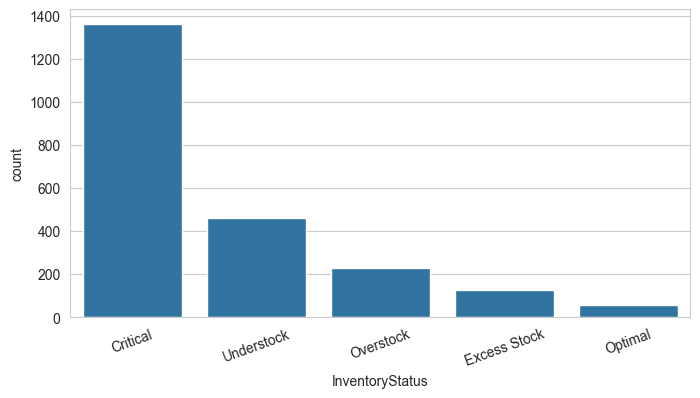

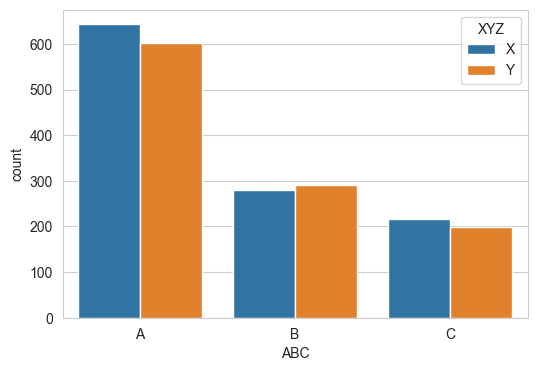

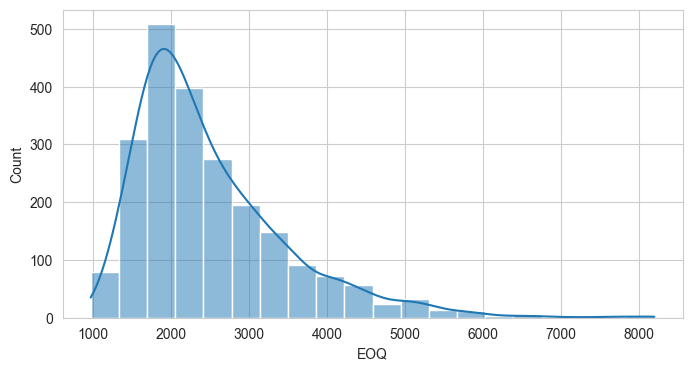

In [6]:
fig,ax=plt.subplots(figsize=(8,4))
sns.countplot(data=inventory,x="InventoryStatus",order=inventory["InventoryStatus"].value_counts().index,ax=ax)
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=inventory,x="ABC",hue="XYZ")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(inventory["EOQ"],bins=20,kde=True)
plt.show()


In [7]:
out=Path("../data/processed")
out.mkdir(parents=True,exist_ok=True)

inventory.to_csv(out/"inventory_optimization.csv",index=False)
inventory[["ProductID","ABC"]].to_csv(out/"abc_analysis.csv",index=False)
inventory[["ProductID","XYZ"]].to_csv(out/"xyz_analysis.csv",index=False)
inventory[["ProductID","ABC_XYZ"]].to_csv(out/"abc_xyz_matrix.csv",index=False)
inventory[["ProductID","Recommendation"]].to_csv(out/"inventory_recommendations.csv",index=False)
kpi.to_csv(out/"inventory_kpis.csv",index=False)

print("Export complete")


Export complete
